<a href="https://colab.research.google.com/github/mohammadzav23-ux/Mohammad_DTSC3020_Fall2025/blob/main/Assignment_2_4501_Fall2026_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTSC 4501 — Assignment 2

**The assignment focuses on the contents covered in Week 3 and Week 4 (or Module 3 and Module 4). All questions are coding-only. Upload this notebook (`.ipynb`) and an exported PDF file to Canvas.**

## Learning goals
- Create and manipulate **NumPy arrays** (vectorized operations, ranges, basic functions)
- Create and manipulate **tables** using **pandas DataFrames**
- Use DataFrame methods for selection, filtering, creating new columns
- Make basic **visualizations** (bar chart, histogram, scatter plot)
- Work with **distributions** (counts, proportions, bins)
- Write **functions**, use **lists**, and apply functions to table columns (`apply`)
- Use table operations: `groupby`, `pivot_table`, `merge` (join)


## Part 0 - Setup cells

Run the following cells first for environment setup and dataset synthesis.

In [1]:
# Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(4501)

In [2]:
# Create a small synthetic dataset for the assignment (run once)
# This writes two CSVs into the working directory:
#   - patients.csv
#   - clinics.csv

n = 240

clinics = np.random.choice(['North', 'South', 'East', 'West'], size=n, p=[0.28, 0.24, 0.26, 0.22])
months  = np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'], size=n, p=[0.15, 0.16, 0.17, 0.18, 0.17, 0.17])

age  = np.random.randint(18, 81, size=n)                        # numerical
bmi  = np.round(np.random.normal(loc=27, scale=5, size=n), 1)   # numerical
bmi  = np.clip(bmi, 16, 48)

smoker = np.random.choice(['Yes', 'No'], size=n, p=[0.22, 0.78]) # categorical
steps  = np.random.randint(500, 16000, size=n)                   # numerical

# A simple visit cost model with noise
base_cost = 65 + 1.2*age + 3.0*(bmi-22) + np.where(smoker=='Yes', 85, 0) + np.random.normal(0, 25, size=n)
cost = np.round(np.clip(base_cost, 35, None), 2)

patients_df = pd.DataFrame({
    'Clinic': clinics,
    'Month': months,
    'Age': age,
    'BMI': bmi,
    'Smoker': smoker,
    'StepsPerDay': steps,
    'VisitCost': cost
})

clinics_df = pd.DataFrame({
    'Clinic': ['North', 'South', 'East', 'West'],
    'DiscountRate': [0.05, 0.08, 0.03, 0.06],  # fraction
    'Manager': ['N. Lee', 'S. Patel', 'E. Kim', 'W. Garcia']
})

patients_df.to_csv("patients.csv", index=False)
clinics_df.to_csv("clinics.csv", index=False)

patients_df.head(), clinics_df


(  Clinic Month  Age   BMI Smoker  StepsPerDay  VisitCost
 0   East   Mar   62  29.9     No         1903     150.70
 1   East   May   74  32.1     No        14907     186.90
 2   East   Apr   51  35.1     No         2716     194.06
 3   East   Jan   60  31.3     No        13796     179.70
 4   East   Jun   22  26.9     No        11909      99.99,
   Clinic  DiscountRate    Manager
 0  North          0.05     N. Lee
 1  South          0.08   S. Patel
 2   East          0.03     E. Kim
 3   West          0.06  W. Garcia)

In [3]:
# Load the tables
patients = pd.read_csv("patients.csv")
clinics  = pd.read_csv("clinics.csv")

patients.head(), clinics

(  Clinic Month  Age   BMI Smoker  StepsPerDay  VisitCost
 0   East   Mar   62  29.9     No         1903     150.70
 1   East   May   74  32.1     No        14907     186.90
 2   East   Apr   51  35.1     No         2716     194.06
 3   East   Jan   60  31.3     No        13796     179.70
 4   East   Jun   22  26.9     No        11909      99.99,
   Clinic  DiscountRate    Manager
 0  North          0.05     N. Lee
 1  South          0.08   S. Patel
 2   East          0.03     E. Kim
 3   West          0.06  W. Garcia)

## Part 1 — Arrays & Ranges

### Q1: NumPy arrays + basic functions (1 point)
Using the `patients` DataFrame:

1. Create NumPy arrays `age` and `bmi` from the `Age` and `BMI` columns.
2. Compute and print:
   - mean age
   - min BMI
   - max BMI
3. Create:
   - `age_plus_5` by adding 5 to every element of `age` (**vectorized**)
   - `bmi_centered` = BMI − mean(BMI)

**Deliverables:** variables `age`, `bmi`, `age_plus_5`, `bmi_centered` and printed results.


In [4]:
# Q1
# Extract columns into NumPy arrays
age = patients["Age"].to_numpy()
bmi = patients["BMI"].to_numpy()

# Compute stats with NumPy
avg_age = np.mean(age)
min_bmi = np.min(bmi)
max_bmi = np.max(bmi)

print("avg_age =", avg_age)
print("min_bmi =", min_bmi)
print("max_bmi =", max_bmi)

# Vectorized arithmetic
age_plus_5 = age + 5
bmi_centered = bmi - np.mean(bmi)


avg_age = 49.4125
min_bmi = 16.0
max_bmi = 44.0


### Q2: Ranges + bins (distribution thinking) (1 point)
Create age bin edges from 18 to 82 with step 8 using `np.arange`.

1. Create `age_bins`.
2. Use `pd.cut` with `right=False` (left-closed, right-open bins) to bin ages.
3. Create a frequency table `age_dist` (counts per bin).

**Deliverables:** `age_bins`, `age_dist` (a pandas Series or DataFrame).


In [5]:
# Q2
age_bins = np.arange(18, 82, 8)

age_bin_labels = pd.cut(patients["Age"], bins=age_bins, right=False)
age_dist = age_bin_labels.value_counts().sort_index()

age_dist

,count
Age,
"[18, 26)",30
"[26, 34)",22
"[34, 42)",34
"[42, 50)",30
"[50, 58)",31
"[58, 66)",39
"[66, 74)",32


## Part 2 — Tables (DataFrames) & Basic Methods

### Q3: Create a summary table (DataFrame) (1 point)
Create a DataFrame `summary` with columns:
- `Metric`: `["AvgAge", "AvgBMI", "PctSmokerYes"]`
- `Value`: the computed values from `patients`

Notes:
- `PctSmokerYes` should be in **percent 0–100** (not a fraction).
- Use filtering to count smokers.

**Deliverable:** `summary`.


In [6]:
# Q3
avg_age = patients["Age"].mean()
avg_bmi = patients["BMI"].mean()

num_yes = (patients["Smoker"] == "Yes").sum()
pct_smoker_yes = (num_yes / len(patients)) * 100

summary = pd.DataFrame({
    "Metric": ["AvgAge", "AvgBMI", "PctSmokerYes"],
    "Value": [avg_age, avg_bmi, pct_smoker_yes]
})

summary

,Metric,Value
0,AvgAge,49.412500
1,AvgBMI,27.072500
2,PctSmokerYes,20.416667


### Q4: Attribute types + visualization (bar vs histogram) (0.5 point)
1. Make a **bar chart** of counts by `Clinic` (categorical).
2. Make a **histogram** of `VisitCost` using **10 bins** (numerical).

**Deliverables:** both plots.


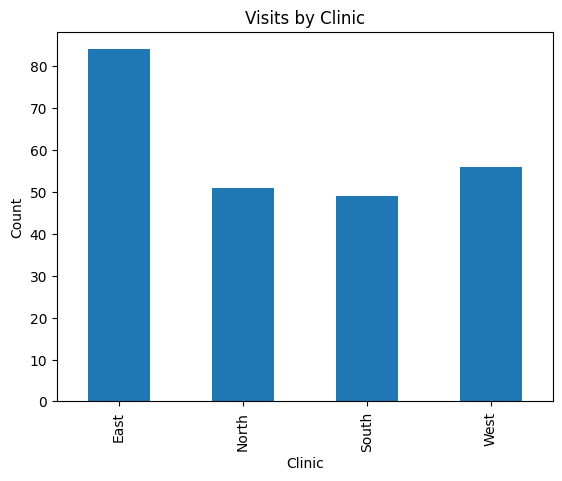

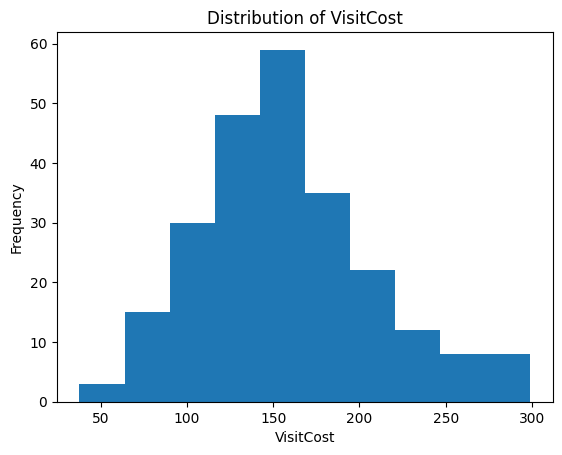

In [7]:
# Q4

# Bar chart: Clinic counts
clinic_counts = patients["Clinic"].value_counts().sort_index()

plt.figure()
clinic_counts.plot(kind="bar")
plt.xlabel("Clinic")
plt.ylabel("Count")
plt.title("Visits by Clinic")
plt.show()

# Histogram: VisitCost
plt.figure()
plt.hist(patients["VisitCost"], bins=10)
plt.xlabel("VisitCost")
plt.ylabel("Frequency")
plt.title("Distribution of VisitCost")
plt.show()

### Q5: Scatter plot + correlation (0.5 point)
1. Make a scatter plot with:
   - x = `StepsPerDay`
   - y = `VisitCost`
2. Compute the correlation coefficient between these columns using `np.corrcoef`.

**Deliverables:** scatter plot + `corr_steps_cost` (a single number).


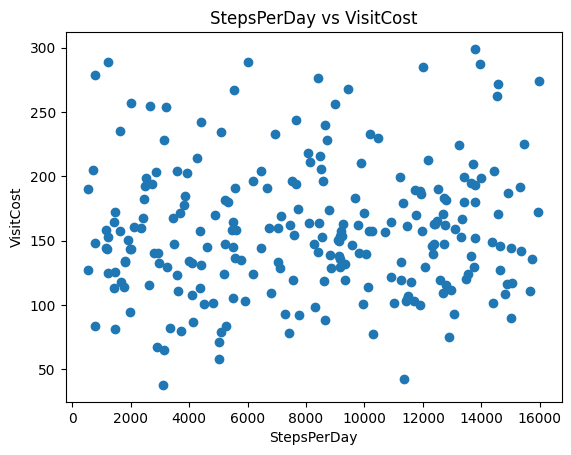

np.float64(0.0655667287735129)

In [8]:
# Q5

plt.figure()
plt.scatter(patients["StepsPerDay"], patients["VisitCost"])
plt.xlabel("StepsPerDay")
plt.ylabel("VisitCost")
plt.title("StepsPerDay vs VisitCost")
plt.show()

steps = patients["StepsPerDay"].to_numpy()
cost = patients["VisitCost"].to_numpy()

corr_matrix = np.corrcoef(steps, cost)
corr_steps_cost = corr_matrix[0, 1]

corr_steps_cost

## Part 3 — Functions + `apply`

### Q6: Write and test functions (1 point)
Write two Python functions:

1. `bmi_category(bmi_value)` returns:
   - `'Under'` if BMI < 18.5
   - `'Normal'` if 18.5 ≤ BMI < 25
   - `'Over'` if 25 ≤ BMI < 30
   - `'Obese'` if BMI ≥ 30
2. `risk_points(age_value, smoker_value)` returns an **integer**:
   - +2 if age ≥ 60
   - +3 if smoker is `'Yes'`

Test your functions with at least **3** example calls total.

**Deliverables:** both functions + tests.


In [9]:
# Q6

def bmi_category(bmi_value):
    if bmi_value < 18.5:
        return "Under"
    elif bmi_value < 25:
        return "Normal"
    elif bmi_value < 30:
        return "Over"
    else:
        return "Obese"


def risk_points(age_value, smoker_value):
    points = 0

    if age_value >= 60:
        points += 2

    if smoker_value == "Yes":
        points += 3

    return points


# Tests
bmi_category(17.9), bmi_category(23.0), bmi_category(31.2)

('Under', 'Normal', 'Obese')

### Q7: Use `apply` to create new columns (1 point)
1. Create `BMICategory` using your `bmi_category` function applied to the `BMI` column.
2. Create `RiskPoints` using your `risk_points` function, based on `Age` and `Smoker`.
   - Hint: you can use `DataFrame.apply` with `axis=1`, or another method you learned.

Create a new DataFrame `patients2` that includes these new columns.

**Deliverable:** `patients2` (show first 5 rows).


In [10]:
# Q7

patients2 = patients.copy()

# Apply bmi_category to BMI
patients2["BMICategory"] = patients2["BMI"].apply(bmi_category)

# Apply risk_points using Age + Smoker
patients2["RiskPoints"] = patients2.apply(
    lambda row: risk_points(row["Age"], row["Smoker"]),
    axis=1
)

patients2.head()

,Clinic,Month,Age,BMI,Smoker,StepsPerDay,VisitCost,BMICategory,RiskPoints
0,East,Mar,62,29.9,No,1903,150.70,Over,2
1,East,May,74,32.1,No,14907,186.90,Obese,2
2,East,Apr,51,35.1,No,2716,194.06,Obese,0
3,East,Jan,60,31.3,No,13796,179.70,Obese,2
4,East,Jun,22,26.9,No,11909,99.99,Over,0


## Part 4 — `groupby`, `pivot_table`, `merge`

### Q8: `groupby` summaries (1 point)
Using `patients2`:

1. Create `cost_by_clinic`: average `VisitCost` per `Clinic`.
2. Create `cost_by_clinic_smoker`: average `VisitCost` per (`Clinic`, `Smoker`).

**Deliverables:** `cost_by_clinic`, `cost_by_clinic_smoker` (as DataFrames).


In [11]:
# Q8

cost_by_clinic = patients2.groupby("Clinic")["VisitCost"].mean().reset_index()

cost_by_clinic_smoker = (
    patients2.groupby(["Clinic", "Smoker"])["VisitCost"]
    .mean()
    .reset_index()
)

cost_by_clinic, cost_by_clinic_smoker.head()

(  Clinic   VisitCost
 0   East  158.175238
 1  North  155.781569
 2  South  155.594898
 3   West  160.953929,
   Clinic Smoker   VisitCost
 0   East     No  143.623857
 1   East    Yes  230.932143
 2  North     No  138.317674
 3  North    Yes  249.650000
 4  South     No  134.787692)

### Q9: `pivot_table` cross-tabulation (counts) (1 point)
Create a pivot table `visits_grid` with:
- rows = `Month`
- columns = `Clinic`
- values = counts of rows (visits)

Then compute (in code):
- `top_month`: the month with the largest **total** number of visits across all clinics.

**Deliverables:** `visits_grid`, `top_month`.


In [12]:
# Q9

visits_grid = pd.pivot_table(
    patients2,
    index="Month",
    columns="Clinic",
    values="VisitCost",
    aggfunc="size",
    fill_value=0
)

visits_grid

# Total visits per month
row_totals = visits_grid.sum(axis=1)

# Month with largest total number of visits
top_month = row_totals.idxmax()

top_month

'Mar'

### Q10: `merge` (join) + new computed column (1 point)
1. Join `patients2` with `clinics` on `Clinic` to bring `DiscountRate` into the patient table.
2. Create `DiscountedCost` = `VisitCost * (1 - DiscountRate)`.
3. Create `avg_discounted_by_clinic`: average `DiscountedCost` per clinic.

**Deliverables:** `patients3`, `avg_discounted_by_clinic`.


In [13]:
# Q10

patients3 = patients2.merge(
    clinics[["Clinic", "DiscountRate"]],
    on="Clinic",
    how="left"
)

patients3["DiscountedCost"] = (
    patients3["VisitCost"] * (1 - patients3["DiscountRate"])
)

avg_discounted_by_clinic = (
    patients3.groupby("Clinic")["DiscountedCost"]
    .mean()
    .reset_index()
)

avg_discounted_by_clinic

,Clinic,DiscountedCost
0,East,153.429981
1,North,147.992490
2,South,143.147306
3,West,151.296693


## Part 5 — Lists for analysis workflows (Week 4)

### Q11: Use a list to loop through numeric columns (1 point)
Create a Python list `num_cols` that contains the labels of **numeric columns** in `patients3`.  
(Choose from: `Age`, `BMI`, `StepsPerDay`, `VisitCost`, `RiskPoints`, `DiscountRate`, `DiscountedCost`.)

Then write a loop that prints each label and the mean of that column.

**Deliverables:** `num_cols` + printed output.


In [14]:
# Q11

num_cols = [
    "Age",
    "BMI",
    "StepsPerDay",
    "VisitCost",
    "RiskPoints",
    "DiscountRate",
    "DiscountedCost"
]

for c in num_cols:
    print(c, "mean =", np.mean(patients3[c].to_numpy()))

Age mean = 49.4125
BMI mean = 27.072499999999998
StepsPerDay mean = 8074.766666666666
VisitCost mean = 157.78812499999998
RiskPoints mean = 1.2791666666666666
DiscountRate mean = 0.05145833333333334
DiscountedCost mean = 149.6773675


## Optional sanity check (not graded)
Run this to see if your key variables exist.


In [15]:
required = [
    "age", "bmi", "age_plus_5", "bmi_centered",
    "age_bins", "age_dist", "summary",
    "corr_steps_cost",
    "patients2", "patients3",
    "cost_by_clinic", "cost_by_clinic_smoker",
    "visits_grid", "top_month",
    "avg_discounted_by_clinic",
    "num_cols"
]
missing = [v for v in required if v not in globals()]
print("Missing:", missing if missing else "None ✅")


Missing: None ✅
